In [1]:
pip install pandas numpy matplotlib seaborn scipy statsmodels jupyter


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
#Reading datasets
demo = pd.read_csv("df_final_demo.csv")
web1 = pd.read_csv("df_final_web_data_pt_1.csv")
web2 = pd.read_csv("df_final_web_data_pt_2.csv")
experiment = pd.read_csv("df_final_experiment_clients.csv")

In [4]:
#merging the datasets
web = pd.concat([web1, web2], ignore_index=True)

In [5]:
#Phase1 EDA 
#inspect dataset
demo.shape
web1.shape
web2.shape
experiment.shape

(70609, 2)

In [6]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [7]:
demo.shape

(70609, 9)

In [8]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [9]:
#finding missing counts
demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [10]:
#droping missing values
demo.dropna(inplace=True)

In [11]:
demo.isnull().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

In [12]:
#checking duplicates
demo.duplicated().sum()

np.int64(0)

In [13]:
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.059400e+04,70594.000000,70594.000000,70594.000000,70594.000000,7.059400e+04,70594.000000,70594.000000
mean,5.005026e+06,12.053007,150.659999,46.442240,2.255532,1.474467e+05,3.382469,5.566720
std,2.877289e+06,6.871850,82.090264,15.591273,0.535000,3.015106e+05,2.236595,2.353296
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519543e+06,6.000000,82.000000,32.500000,2.000000,3.734660e+04,1.000000,4.000000
50%,5.016974e+06,11.000000,136.000000,47.000000,2.000000,6.333459e+04,3.000000,5.000000
75%,7.483074e+06,16.000000,192.000000,59.000000,2.000000,1.375461e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [15]:
#Visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

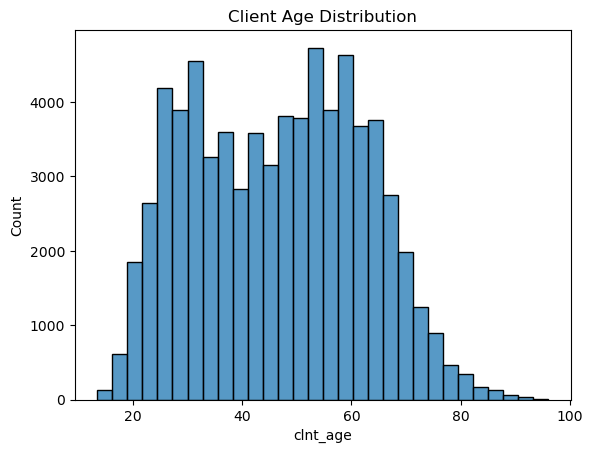

In [16]:
#Age Distribution
sns.histplot(demo['clnt_age'], bins=30)
plt.title("Client Age Distribution")
plt.show()

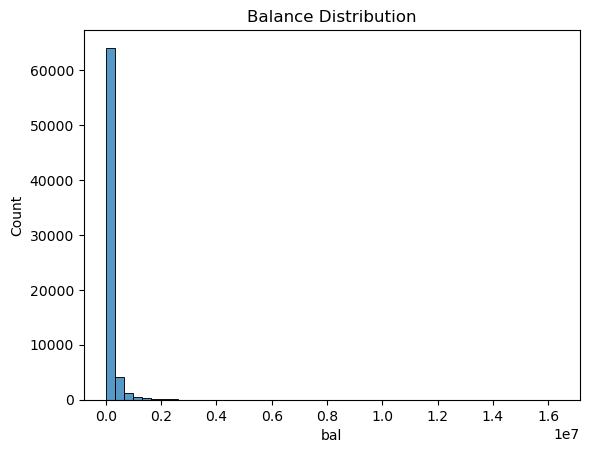

In [17]:
#Balance Distribution
sns.histplot(demo['bal'], bins=50)
plt.title("Balance Distribution")
plt.show()

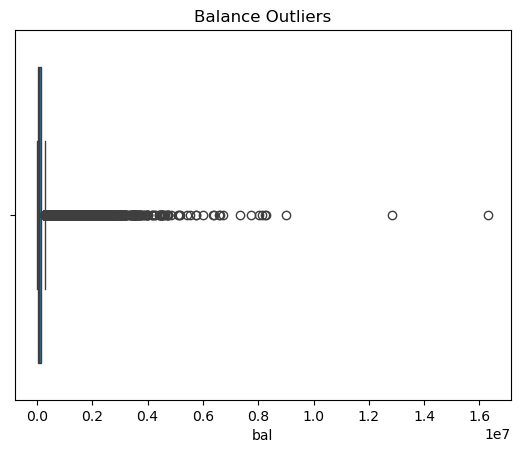

In [18]:
#Balance Boxplot
sns.boxplot(x=demo['bal'])
plt.title("Balance Outliers")
plt.show()

In [19]:
#gender distribution
demo['gendr'].value_counts()

gendr
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64

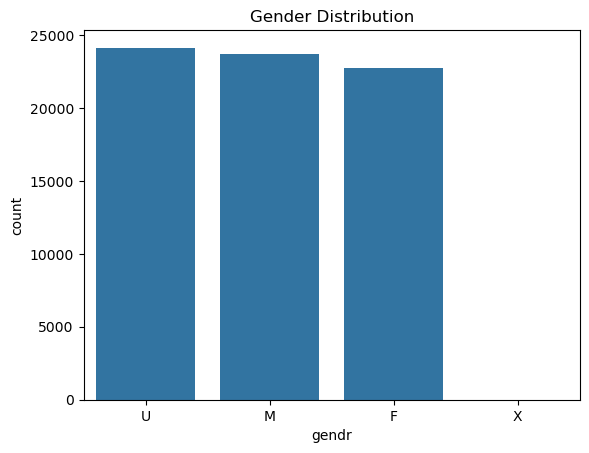

In [20]:
sns.countplot(x='gendr', data=demo)
plt.title("Gender Distribution")
plt.show()

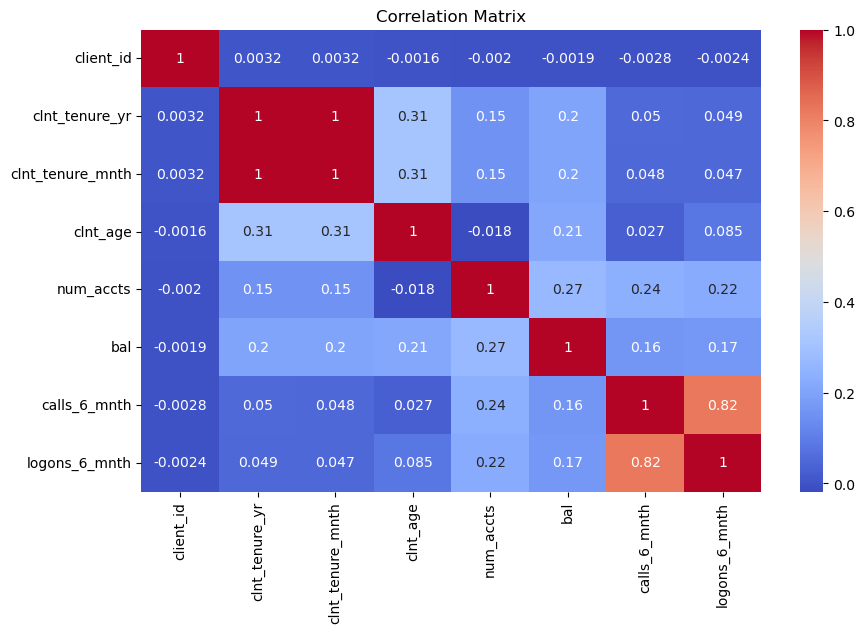

In [21]:
#Correlation Analysis helps identify relationships between variables
corr = demo.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [22]:
experiment.head()
experiment.info()
experiment.isnull().sum()
experiment.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


,client_id,Variation
count,7.060900e+04,50500
unique,NaN,2
top,NaN,Test
freq,NaN,26968
mean,5.004992e+06,NaN
std,2.877278e+06,NaN
min,1.690000e+02,NaN
25%,2.519329e+06,NaN
50%,5.016978e+06,NaN
75%,7.483085e+06,NaN


In [23]:
#EDA for Experiment dataset
experiment = experiment.dropna(subset=['Variation'])

In [24]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50500 entries, 0 to 50499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  50500 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.2+ MB


In [25]:
experiment['Variation'].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [ ]:
#Insights
#The experiment dataset contains 50,500 participating clients
#The test group includes 26,968 clients, while the control group contains 23,532 clients
#Although the groups are not perfectly equal in size, they remain reasonably balanced for experimental comparison.

In [26]:
#percentage calculation
experiment['Variation'].value_counts(normalize=True) * 100

Variation
Test       53.40198
Control    46.59802
Name: proportion, dtype: float64

In [ ]:
#The test groüp is slighty larger
#53.4% vs 46.6%

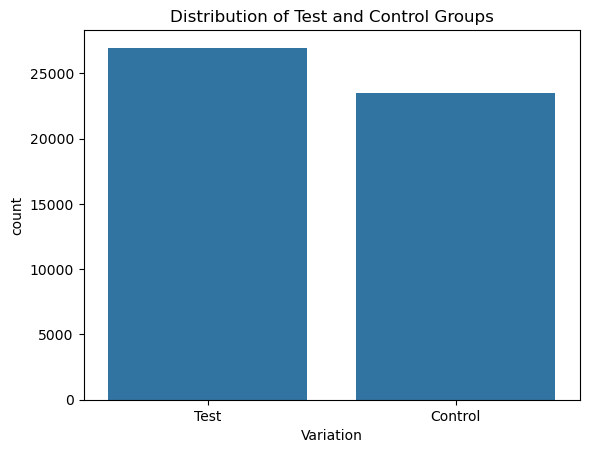

In [27]:
#Visualization of Experiment dataset
sns.countplot(x='Variation', data=experiment)
plt.title("Distribution of Test and Control Groups")
plt.show()

In [28]:
#User Journey Analysis
web['process_step'].value_counts()

process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64

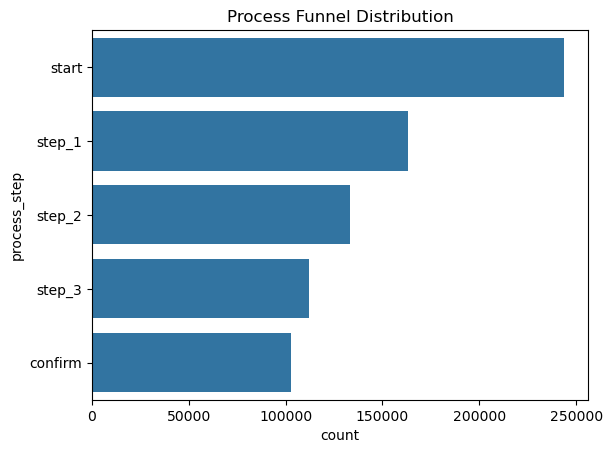

In [29]:
sns.countplot(
    y='process_step',
    data=web,
    order=web['process_step'].value_counts().index
)

plt.title("Process Funnel Distribution")
plt.show()

In [ ]:
#Insights
#User participation decreases progressively across the digital process funnel
#The largest drop-off occurs between the start page and step 1, suggesting potential usability or engagement friction early in the process
#Users who reach later stages demonstrate a significantly higher likelihood of completing the process.

In [30]:
#Merging datasets
df = web.merge(experiment, on='client_id')

In [31]:
df = df.merge(demo, on='client_id')

In [32]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321195 entries, 0 to 321194
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         321195 non-null  int64  
 1   visitor_id        321195 non-null  object 
 2   visit_id          321195 non-null  object 
 3   process_step      321195 non-null  object 
 4   date_time         321195 non-null  object 
 5   Variation         321195 non-null  object 
 6   clnt_tenure_yr    321195 non-null  float64
 7   clnt_tenure_mnth  321195 non-null  float64
 8   clnt_age          321195 non-null  float64
 9   gendr             321195 non-null  object 
 10  num_accts         321195 non-null  float64
 11  bal               321195 non-null  float64
 12  calls_6_mnth      321195 non-null  float64
 13  logons_6_mnth     321195 non-null  float64
dtypes: float64(7), int64(1), object(6)
memory usage: 34.3+ MB


(321195, 14)

In [33]:
#Phase2 Performance Metrics
#Convert date_time to datetime
df['date_time'] = pd.to_datetime(df['date_time'])

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321195 entries, 0 to 321194
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   client_id         321195 non-null  int64         
 1   visitor_id        321195 non-null  object        
 2   visit_id          321195 non-null  object        
 3   process_step      321195 non-null  object        
 4   date_time         321195 non-null  datetime64[ns]
 5   Variation         321195 non-null  object        
 6   clnt_tenure_yr    321195 non-null  float64       
 7   clnt_tenure_mnth  321195 non-null  float64       
 8   clnt_age          321195 non-null  float64       
 9   gendr             321195 non-null  object        
 10  num_accts         321195 non-null  float64       
 11  bal               321195 non-null  float64       
 12  calls_6_mnth      321195 non-null  float64       
 13  logons_6_mnth     321195 non-null  float64       
dtypes: d

In [35]:
#FIRST KPI — Completion Rate
#1 Identify completed users
completed = df[df['process_step'] == 'confirm']

In [36]:
#2 Count Unique Completed Clients
completed_clients = completed['client_id'].nunique()
completed_clients


34110

In [37]:
#3 Count Total Clients
total_clients = df['client_id'].nunique()
total_clients

50487

In [38]:
#4Calculate Completion Rate
#Completion Rate=Clients who reached confirm /total clients × 100
completion_rate = (completed_clients / total_clients) * 100
completion_rate




67.56194663972904

In [39]:
#5 Completion by Variation
#Calculate completion rate by:Test vs Control
#Completed users by group

completed_by_group = (
    completed.groupby('Variation')['client_id']
    .nunique()
)

completed_by_group

Variation
Control    15428
Test       18682
Name: client_id, dtype: int64

In [40]:
#6 Total users by group
total_by_group = (
    df.groupby('Variation')['client_id']
    .nunique()
)

total_by_group

Variation
Control    23526
Test       26961
Name: client_id, dtype: int64

In [41]:
#7 Completion Rates by Group
completion_rates = (
    completed_by_group / total_by_group
) * 100

completion_rates

Variation
Control    65.578509
Test       69.292682
Name: client_id, dtype: float64

In [ ]:
#Insights
#The redesigned interface (Test group) achieved a higher completion rate than the traditional interface (Control group).
#Difference:69.29% - 65.58% = 3.71 percentage points
#Clients exposed to the redesigned digital interface achieved a completion rate of 69.29%, 
#compared to 65.58% for clients using the traditional interface.
#This indicates that the redesigned experience improved process completion by approximately 3.7 percentage points.

In [42]:
#Progression by variation#
pd.crosstab(df['process_step'], df['Variation'])

Variation,Control,Test
process_step,,
confirm,17498,25716
start,47589,56452
step_1,29657,38753
step_2,25877,30978
step_3,22787,25888


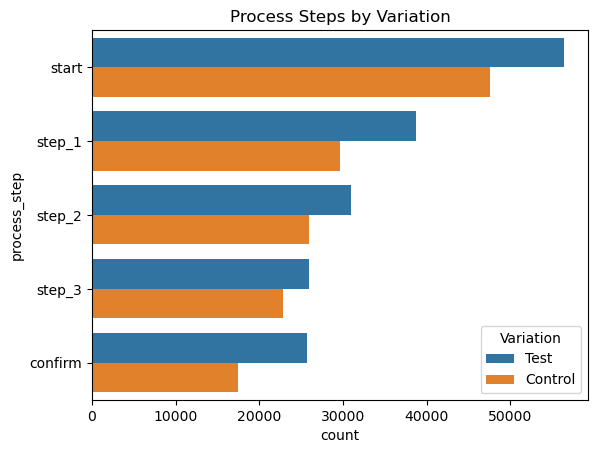

In [45]:
#Visualization
sns.countplot(
    y='process_step',
    hue='Variation',
    data=df,
    order=['start', 'step_1', 'step_2', 'step_3', 'confirm']
)

plt.title("Process Steps by Variation")
plt.show()

In [ ]:
#The Test group consistently outperforms the Control group across every funnel stage.

In [47]:
#calculate Retention
process_analysis = pd.crosstab(df['process_step'], df['Variation'])

process_analysis_pct = (
    process_analysis.div(process_analysis.loc['start']) * 100
)

process_analysis_pct

Variation,Control,Test
process_step,,
confirm,36.769001,45.553745
start,100.000000,100.000000
step_1,62.319023,68.647701
step_2,54.376011,54.874938
step_3,47.882914,45.858428


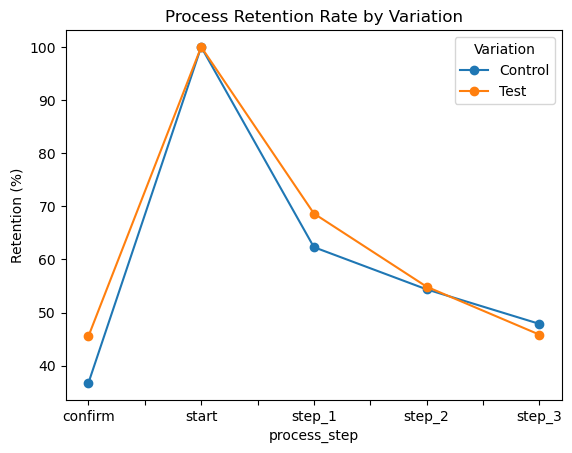

In [50]:
funnel_pct.plot(marker='o')

plt.title("Process Retention Rate by Variation")
plt.ylabel("Retention (%)")
plt.show()